In [58]:
from IPython.display import Image, display, SVG, HTML

from typing import Dict, List, Tuple

from interval_timeline import CallGraph
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import re

import otf2
import hatchet as ht
import thicket as tt

In [59]:
# ACTIVE_PERIODS_MS = [1, 5, 20, 30, 50, 75, 100, 150, 200, 400, 600, 800, 1000]
# IDLE_PERIODS_MS = [1, 5, 20, 30, 50, 75, 100, 150, 200, 400, 600, 800, 1000]


IDLE_PERIODS_MS = [600]
ACTIVE_PERIODS_MS = [600]
# IDLE_PERIODS_MS = [1, 5, 20, 50, 100, 200, 400, 600]
# ACTIVE_PERIODS_MS = [1, 5, 20, 50, 100, 200, 400, 600]
# ACTIVE_VALUES=(1 5 20 30 50 75 100 150 200 400 600 800 1000)
# IDLE_PERIODS_MS = [5]
# ACTIVE_PERIODS_MS = [500]
# IDLE_PERIODS_MS = [500]
# ACTIVE_PERIODS_MS = [5]
def get_run_trace_path(idle_period_ms: int, active_period_ms: int) -> str:
    """Get the path to the run trace file based on idle and active periods."""
    return f"scorep-traces/idle-compute-step-8-freq-and-capped/idle-compute-step-{idle_period_ms}ms-{active_period_ms}ms/traces.otf2"

# IDLE_PERIODS_MS = [400]
# ACTIVE_PERIODS_MS = [800]
# IDLE_PERIODS_MS = [100, 200, 400, 600, 800]
# ACTIVE_PERIODS_MS = [100, 200, 400, 600, 800]
# def get_run_trace_path(idle_period_ms: int, active_period_ms: int) -> str:
#     """Get the path to the run trace file based on idle and active periods."""
#     return f"scorep-traces/idle-compute-step-2/idle-compute-step-{idle_period_ms}ms-{active_period_ms}ms/traces.otf2"

In [60]:
# TRACE_DIR = "./scorep-traces/mi300-multiple-kernels-two-gpus/traces.otf2"
PROCESSES_TO_TRACK = [
    'Process',
    # 'MPI Rank 0',
]
METRICS_TO_TRACK = [
    'A2rocm_smi:::energy_count:device=0',
    'A2rocm_smi:::energy_count:device=2',
    'A2rocm_smi:::energy_count:device=4',
    'A2rocm_smi:::energy_count:device=6',
    
    'A2coretemp:::craypm:accel0_energy',
    'A2coretemp:::craypm:accel1_energy',
    'A2coretemp:::craypm:accel2_energy',
    'A2coretemp:::craypm:accel3_energy',
    
    'A3coretemp:::craypm:accel0_energy',
    'A3coretemp:::craypm:accel1_energy',
    'A3coretemp:::craypm:accel2_energy',
    'A3coretemp:::craypm:accel3_energy',
    
    'A2coretemp:::craypm:accel0_power',
    'A2coretemp:::craypm:accel1_power',
    'A2coretemp:::craypm:accel2_power',
    'A2coretemp:::craypm:accel3_power',

    'A3coretemp:::craypm:accel0_power',
    'A3coretemp:::craypm:accel1_power',
    'A3coretemp:::craypm:accel2_power',
    'A3coretemp:::craypm:accel3_power',
]

def callgraph_to_csv(call_graph: CallGraph, group: str, thread: str, filename: str):
    """Convert a CallGraph to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Thread,Group,Depth,Name,Start Time,End Time,Duration\n")
        intervals = call_graph.get_intervals_between(0, float('inf'))
        
        for interval in intervals:
            start = interval.start
            end = interval.end or float('inf')
            duration = end - start
            name = interval.name if interval.name else "Unknown"
            depth = interval.depth if interval.depth else 0

            f.write(f"{thread},{group},{depth},\"{name}\",{start},{end},{duration}\n")

def metrics_to_csv(group: str, thread_metrics: Dict[str, List[Tuple[float, float]]], filename: str):
    """Convert metrics to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Group,Metric Name,Time,Value\n")
        for metric_name, values in thread_metrics.items():
            for time, value in values:
                f.write(f"{group},{metric_name},{time},{value}\n")

def read_metrics_dataframe(file: str) -> pd.DataFrame:
    df = pd.read_csv(file)
    # For all the rocm metrics, divide by 1e6 to convert from uJ to J
    for metric_name in df['Metric Name'].unique():
        if 'rocm_smi:::energy_count:device' in metric_name:
            df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000
    return df

def read_call_graph_dataframe(file: str) -> pd.DataFrame:
    return pd.read_csv(file)


In [61]:
def trace_to_csv(trace: str, processes_to_track: List[str], metrics_to_track: List[str]):
    call_graphs = {}
    metrics = {}

    start_time = None
    timer_resolution = None

    seen: Dict[str, set[str]] = {}

    def timestamp_to_seconds(timestamp):
        """Convert a timestamp in nanoseconds to seconds."""
        if timestamp is None or start_time is None or timer_resolution is None:
            return 0.0
        return (timestamp - start_time) / timer_resolution

    with otf2.reader.open(trace) as reader:
        defs = reader.definitions
        timer_resolution = reader.timer_resolution
        print(f"Timer resolution: {timer_resolution} ticks per second ({timer_resolution / 1e9} per nanosecond)")
        print(f"Number of metric members: {len(defs.metric_members)}")
        print(f'Definitions: {defs}')
        count = 0
        for location, event in reader.events:
            count += 1
            # thread = (location.name, location.group.name)
            group = location.group.name
            if location.group.creating_location_group is not None:
                group = location.group.creating_location_group.name
            thread = location.name
            
            if group not in seen:
                seen[group] = set()
            if thread not in seen[group]:
                seen[group].add(thread)
                print(f"New thread: {thread} in group {group}")
            if group not in call_graphs:
                call_graphs[group] = {thread: CallGraph()}
            if thread not in call_graphs[group]:
                call_graphs[group][thread] = CallGraph()
            if group not in metrics:
                metrics[group] = {metric: [] for metric in METRICS_TO_TRACK}
            
            if isinstance(event, otf2.events.ProgramBegin):
                start_time = event.time
                continue
            elif isinstance(event, otf2.events.ProgramEnd):
                end_time = event.time
                continue
            
            current_time = timestamp_to_seconds(event.time)
            
            if isinstance(event, otf2.events.Metric):
                metric_name = event.member.name
                if group not in metrics:
                    continue
                if metric_name not in metrics[group]:
                    continue
                if 'cray' in metric_name:
                    current_time -= 0.16  # Adjust for craypm metrics, as they are reported with a delay
                
                if len(metrics[group][metric_name]) == 0 or metrics[group][metric_name][-1][1] != event.value:
                    metrics[group][metric_name].append((current_time, event.value))
                
            if group not in processes_to_track:
                continue
            
            if isinstance(event, otf2.events.Enter):
                call_graphs[group][thread].enter(current_time, name=event.region.name)
            elif isinstance(event, otf2.events.Leave):
                try:
                    call_graphs[group][thread].leave(current_time)
                except Exception as e:
                    print(f"Error leaving call graph for {group} {thread}: {e}")
                    continue
        print(f"Processed {count} events.")
        
    for group, threads in call_graphs.items():
        if group not in processes_to_track:
            print(f"Skipping group {group} as it is not in the processes to track.")
            continue
        for thread, call_graph in threads.items():
            filename = f"{group}_{thread.replace(' ', '_')}_callgraph.csv"
            print(f'Writing to file: {filename}')
            callgraph_to_csv(call_graph, group, thread, filename)

    for group, thread_metrics in metrics.items():
        if group not in processes_to_track:
            print(f"Skipping group {group} as it is not in the processes to track.")
            continue
        filename = f"{group}_metrics.csv"
        print(f'Writing to file: {filename}')
        metrics_to_csv(group, thread_metrics, filename)
    
# Visualize the dataframes
def visualize_dataframe(df):
    """Visualize the first few rows of a DataFrame as HTML."""
    # pd.set_option("display.width", 2400)
    # pd.set_option("display.max_colwidth", 100)
    # pd.set_option("display.max_rows", 20)
    
    display(HTML(df.head(n=20).to_html(index=False)))

# trace_to_csv(TRACE_DIR, PROCESSES_TO_TRACK, METRICS_TO_TRACK)
# visualize_dataframe(read_metrics_dataframe(f"{PROCESSES_TO_TRACK[0]}_metrics.csv"))
# visualize_dataframe(read_call_graph_dataframe(f"{PROCESSES_TO_TRACK[0]}_Master_thread_callgraph.csv"))

In [62]:
def sampled_to_continuous(df, time_col='Time', value_col='Value'):
    t_samples = df[time_col].astype(float)
    y = df[value_col].astype(float)
    # # Get the average time between samples
    # time_between_samples = np.mean(np.diff(t_samples))
    # # Now, how many samples are there in 0.4 seconds?
    # period = 0.4  # seconds
    # print(f"Average time between samples: {time_between_samples} seconds")
    # print(f"Samples per period (0.4 seconds): {ceil(period / time_between_samples)}")
    # # Calculate the number of samples per period
    # samples_per_period = ceil(period / time_between_samples)    
    
    # # y = scipy.signal.savgol_filter(y, window_length=samples_per_period, polyorder=2, mode='nearest')
    # # Apply a median filter to smooth the data
    # y = medfilt(y, kernel_size=samples_per_period + samples_per_period % 2 + 1)
 
    # Create a continuous function that interpolates the sampled data
    f = lambda t: np.interp(t, t_samples, y)
    return f

def windowed_average(f, window_period=0.1, sample_period=0.001):
    """
    Return a function F(x) that computes the average of f(t) over a window of size window_size.
    The function F(x) will return a scalar when x is a scalar, and an array when x is an array.
    """
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Create a time grid for the window
        t_grid = np.arange(-window_period / 2, window_period / 2, sample_period)
        # Compute the average over the window
        avg = np.array([np.mean(f(t + t_grid)) for t in x_arr])
        return avg.item() if np.isscalar(x) else avg
    
    return F

def windowed_median(f, window_period=0.1, sample_period=0.001):
    """
    Return a function F(x) that computes the median of f(t) over a window of size window_size.
    The function F(x) will return a scalar when x is a scalar, and an array when x is an array.
    """
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Create a time grid for the window
        t_grid = np.arange(-window_period / 2, window_period / 2, sample_period)
        # Compute the median over the window
        med = np.array([np.median(f(t + t_grid)) for t in x_arr])
        return med.item() if np.isscalar(x) else med
    
    return F

def windowed_savgol(f, sample_period=0.1, polyorder=2):
    """
    Return a function F(x) that applies a Savitzky-Golay filter to f(t) over a window of size window_size.
    The function F(x) will return a scalar when x is a scalar, and an array when x is an array.
    """
    return lambda x: scipy.signal.savgol_filter(
        np.array([f(t) for t in np.atleast_1d(x).astype(float)]),
        window_length=ceil(1/sample_period),  # Convert window size to number of samples
        polyorder=polyorder,
        mode='nearest'
    )

def numerical_derivative(func, h=1e-5):
    """Compute the numerical derivative of a function at a point t."""
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

def numerical_integral(f, a=0.0, dx=1e-1):
    """
    Return a function F(x) that approximates the integral of f(t) dt from t=a to t=x,
    using the trapezoidal rule in a fully vectorized manner.
    The function F(x) will return a scalar when x is a scalar, and an array
    when x is an array.
    """
    # Determinar si f soporta arrays de NumPy
    try:
        _ = f(np.array([a, a + dx]))
        f_np = f
    except Exception:
        f_np = np.vectorize(f)
    
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Manejo de x < a invirtiendo signo
        sign = np.ones_like(x_arr)
        mask = x_arr < a
        sign[mask] = -1
        x_pos = np.where(mask, a + (a - x_arr), x_arr)
        
        # Grid hasta el máximo de x
        xmax = x_pos.max()
        t = np.arange(a, xmax + dx, dx)
        u = f_np(t)
        
        # Suma acumulada de trapecios
        trap_heights = (u[:-1] + u[1:]) / 2
        cum = np.concatenate(([0], np.cumsum(trap_heights * dx)))
        
        # Índices y remanentes
        idx = ((x_pos - a) // dx).astype(int)
        rem = x_pos - (a + idx * dx)
        
        # Valores en fronteras
        f_end = f_np(x_pos)
        f_start = u[idx]
        
        # Integral aproximada
        integral = cum[idx] + (f_start + f_end) * rem / 2
        result = sign * integral
        
        # Devolver escalares cuando corresponda
        return result.item() if np.isscalar(x) else result
    
    return F


In [63]:
# Remove all the old CSV files
for file in os.listdir('.'):
    if file.endswith('.csv'):
        os.remove(file)

In [64]:
def trace_to_csv(trace: str, processes_to_track: List[str], metrics_to_track: List[str]):
    call_graphs = {}
    metrics = {}

    start_time = None
    timer_resolution = None

    seen: Dict[str, set[str]] = {}

    def timestamp_to_seconds(timestamp):
        """Convert a timestamp in nanoseconds to seconds."""
        if timestamp is None or start_time is None or timer_resolution is None:
            return 0.0
        return (timestamp - start_time) / timer_resolution

    with otf2.reader.open(trace) as reader:
        defs = reader.definitions
        timer_resolution = reader.timer_resolution
        print(f"Timer resolution: {timer_resolution} ticks per second ({timer_resolution / 1e9} per nanosecond)")
        print(f"Number of metric members: {len(defs.metric_members)}")
        print(f'Definitions: {defs}')
        count = 0
        for location, event in reader.events:
            count += 1
            # thread = (location.name, location.group.name)
            group = location.group.name
            if location.group.creating_location_group is not None:
                group = location.group.creating_location_group.name
            thread = location.name
            
            if group not in seen:
                seen[group] = set()
            if thread not in seen[group]:
                seen[group].add(thread)
                print(f"New thread: {thread} in group {group}")
            if group not in call_graphs:
                call_graphs[group] = {thread: CallGraph()}
            if thread not in call_graphs[group]:
                call_graphs[group][thread] = CallGraph()
            if group not in metrics:
                metrics[group] = {metric: [] for metric in METRICS_TO_TRACK}
            
            if isinstance(event, otf2.events.ProgramBegin):
                start_time = event.time
                continue
            elif isinstance(event, otf2.events.ProgramEnd):
                end_time = event.time
                continue
            
            current_time = timestamp_to_seconds(event.time)
            
            if isinstance(event, otf2.events.Metric):
                metric_name = event.member.name
                if group not in metrics:
                    continue
                if metric_name not in metrics[group]:
                    continue
                if 'cray' in metric_name:
                    current_time -= 0.16  # Adjust for craypm metrics, as they are reported with a delay
                
                if len(metrics[group][metric_name]) == 0 or metrics[group][metric_name][-1][1] != event.value:
                    metrics[group][metric_name].append((current_time, event.value))
                
            if group not in processes_to_track:
                continue
            
            if isinstance(event, otf2.events.Enter):
                call_graphs[group][thread].enter(current_time, name=event.region.name)
            elif isinstance(event, otf2.events.Leave):
                try:
                    call_graphs[group][thread].leave(current_time)
                except Exception as e:
                    print(f"Error leaving call graph for {group} {thread}: {e}")
                    continue
        print(f"Processed {count} events.")
        
    for group, threads in call_graphs.items():
        if group not in processes_to_track:
            print(f"Skipping group {group} as it is not in the processes to track.")
            continue
        for thread, call_graph in threads.items():
            filename = f"{group}_{thread.replace(' ', '_')}_callgraph.csv"
            print(f'Writing to file: {filename}')
            callgraph_to_csv(call_graph, group, thread, filename)

    for group, thread_metrics in metrics.items():
        if group not in processes_to_track:
            print(f"Skipping group {group} as it is not in the processes to track.")
            continue
        filename = f"{group}_metrics.csv"
        print(f'Writing to file: {filename}')
        metrics_to_csv(group, thread_metrics, filename)
    
# Visualize the dataframes
def visualize_dataframe(df):
    """Visualize the first few rows of a DataFrame as HTML."""
    # pd.set_option("display.width", 2400)
    # pd.set_option("display.max_colwidth", 100)
    # pd.set_option("display.max_rows", 20)
    
    display(HTML(df.head(n=20).to_html(index=False)))

# trace_to_csv(TRACE_DIR, PROCESSES_TO_TRACK, METRICS_TO_TRACK)
# visualize_dataframe(read_metrics_dataframe(f"{PROCESSES_TO_TRACK[0]}_metrics.csv"))
# visualize_dataframe(read_call_graph_dataframe(f"{PROCESSES_TO_TRACK[0]}_Master_thread_callgraph.csv"))

In [65]:
def sampled_to_continuous(df, time_col='Time', value_col='Value'):
    t_samples = df[time_col].astype(float)
    y = df[value_col].astype(float)
    # Apply a savgol filter to smooth the data
    # y = scipy.signal.savgol_filter(y, window_length=11, polyorder=2, mode='nearest')
    # Apply a median filter to smooth the data
    # y = scipy.signal.medfilt(y, kernel_size=11)
 
    # Create a continuous function that interpolates the sampled data
    f = lambda t: np.interp(t, t_samples, y)
    return f

def numerical_derivative(func, h=1e-5):
    """Compute the numerical derivative of a function at a point t."""
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

def numerical_integral(f, a=0.0, dx=1e-1):
    """
    Return a function F(x) that approximates the integral of f(t) dt from t=a to t=x,
    using the trapezoidal rule in a fully vectorized manner.
    The function F(x) will return a scalar when x is a scalar, and an array
    when x is an array.
    """
    # Determinar si f soporta arrays de NumPy
    try:
        _ = f(np.array([a, a + dx]))
        f_np = f
    except Exception:
        f_np = np.vectorize(f)
    
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Manejo de x < a invirtiendo signo
        sign = np.ones_like(x_arr)
        mask = x_arr < a
        sign[mask] = -1
        x_pos = np.where(mask, a + (a - x_arr), x_arr)
        
        # Grid hasta el máximo de x
        xmax = x_pos.max()
        t = np.arange(a, xmax + dx, dx)
        u = f_np(t)
        
        # Suma acumulada de trapecios
        trap_heights = (u[:-1] + u[1:]) / 2
        cum = np.concatenate(([0], np.cumsum(trap_heights * dx)))
        
        # Índices y remanentes
        idx = ((x_pos - a) // dx).astype(int)
        rem = x_pos - (a + idx * dx)
        
        # Valores en fronteras
        f_end = f_np(x_pos)
        f_start = u[idx]
        
        # Integral aproximada
        integral = cum[idx] + (f_start + f_end) * rem / 2
        result = sign * integral
        
        # Devolver escalares cuando corresponda
        return result.item() if np.isscalar(x) else result
    
    return F
        

def create_hatchet_dag(call_graph_df, metrics_df):
    # Add a column for the inclusive energy of each call in the call graph
    call_graph_df = call_graph_df.copy()
        
    # Now create a map of continuous functions for each device
    energy_accumulated = {
        metric_name: sampled_to_continuous(metrics_df[metrics_df['Metric Name'] == metric_name]) if 'energy' in metric_name
        else numerical_integral(sampled_to_continuous(metrics_df[metrics_df['Metric Name'] == metric_name]))
        for metric_name in metrics_df['Metric Name'].unique()
    }

    # Sort the call graph by their start time
    call_graph_df = call_graph_df.sort_values(by='Start Time')
    # 1) Generar lista de eventos
    events = []
    print("Creating events from call graph...")
    for _idx, row in call_graph_df.iterrows():
        duration = row['Duration']
        events.append({
            'type': 'enter',
            'time': row['Start Time'],
            'name': row['Name'],
            'duration': duration,
            'metrics': {metric: energy_accumulated[metric](row['End Time']) - energy_accumulated[metric](row['Start Time'])
              for metric in energy_accumulated.keys()}
        })
        events.append({
            'type': 'exit',
            'time': row['End Time'],
            'name': row['Name'],
            'duration': duration
        })
    print(f"Total events created: {len(events)}")
    
    # 2) Ordenar por tiempo, con 'enter' antes que 'exit' en igualdad
    events.sort(key=lambda e: (e['time'], 0 if e['type']=='enter' else 1))

    # 3) Recorrer eventos y construir DAG
    dag = []
    stack = []
    print("Building DAG from events...")
    for ev in events:
        if ev['type'] == 'enter':
            node = {
                'frame': {'name': ev['name']},
                'metrics': {
                    'time (inc)': ev['duration'],
                    'time': 0.0,  # se calculará al hacer el 'exit'
                } | ev['metrics'],
                'children': []
            }
            if stack:
                stack[-1]['children'].append(node)
            else:
                dag.append(node)
            stack.append(node)

        else:  # ev['type'] == 'exit'
            node = stack.pop()
            # sumar duraciones inclusivas de los hijos
            child_incs = sum(ch['metrics']['time (inc)'] for ch in node['children'])
            # tiempo exclusivo = inclusivo - suma de hijos
            node['metrics']['time'] = node['metrics']['time (inc)'] - child_incs

    print(f"DAG created with {len(dag)} root nodes.")
    return dag

def create_hatchet_graph(call_graph_df, metrics_df):
    print("Creating Hatchet DAG from call graph...")
    dag = create_hatchet_dag(call_graph_df, metrics_df)
    print("DAG created successfully.")
    gf = ht.GraphFrame.from_literal(dag)
    print("GraphFrame created from DAG.")
    # print("Creating Thicket from DAG...")
    # tf = tt.Thicket.from_literal(dag)
    # print("Thicket created from DAG.")
    # tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
    return gf

def create_thicket_graph(call_graph_df, metrics_df):
    """Create a Thicket graph from the call graph and metrics DataFrame."""
    print("Creating Hatchet DAG from call graph...")
    dag = create_hatchet_dag(call_graph_df, metrics_df)
    print("DAG created successfully.")
    gf = ht.GraphFrame.from_literal(dag)
    print("GraphFrame created from DAG.")
    
    # Create a Thicket from the DAG
    tf = tt.Thicket.from_literal(dag)
    print("Thicket created from DAG.")
    tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
    
    return gf, tf

def create_hatchet_and_thicket_graphs(call_graph_df, metrics_df):
    """Create a Thicket graph from the call graph and metrics DataFrame."""
    print("Creating Hatchet DAG from call graph...")
    dag = create_hatchet_dag(call_graph_df, metrics_df)
    print("DAG created successfully.")
    gf = ht.GraphFrame.from_literal(dag)
    print("GraphFrame created from DAG.")
    
    # Create a Thicket from the DAG
    tf = tt.Thicket.from_literal(dag)
    print("Thicket created from DAG.")
    tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
    return gf, tf

In [66]:
def load_trace(idle_period_ms: int, active_period_ms: int):
    """Load the trace for a specific idle and active period."""
    try:
        trace_path = get_run_trace_path(idle_period_ms, active_period_ms)
        if not os.path.exists(trace_path):
            raise FileNotFoundError(f"Trace file {trace_path} does not exist.")
        print(f"Loading trace from {trace_path} for idle period {idle_period_ms} ms and active period {active_period_ms} ms.")
        trace_to_csv(trace_path, PROCESSES_TO_TRACK, METRICS_TO_TRACK)
        # Load the CSV files into dataframes
        metrics_df = read_metrics_dataframe(f"{PROCESSES_TO_TRACK[0]}_metrics.csv")
        call_graph_df = read_call_graph_dataframe(f"{PROCESSES_TO_TRACK[0]}_Master_thread_callgraph.csv")
    except Exception as e:
        print(f"Error loading trace: {e}")
        metrics_df = pd.DataFrame(columns=['Group', 'Metric Name', 'Time', 'Value'])
        call_graph_df = pd.DataFrame(columns=['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'])
    return metrics_df, call_graph_df

traces = {
    (idle_period_ms, active_period_ms): load_trace(idle_period_ms, active_period_ms)
    for idle_period_ms in IDLE_PERIODS_MS
    for active_period_ms in ACTIVE_PERIODS_MS
}

Loading trace from scorep-traces/idle-compute-step-8-freq-and-capped/idle-compute-step-600ms-600ms/traces.otf2 for idle period 600 ms and active period 600 ms.
Timer resolution: 1000000000 ticks per second (1.0 per nanosecond)
Number of metric members: 13
Definitions: <otf2.registry.DefinitionRegistry object at 0x13b4dc690>
New thread: Master thread in group Process
New thread:  in group Process
New thread: Per process metrics in group Process
New thread: HIP[0:0] in group Process
Processed 839020 events.
Writing to file: Process_Master_thread_callgraph.csv
Writing to file: Process__callgraph.csv
Writing to file: Process_Per_process_metrics_callgraph.csv
Writing to file: Process_HIP[0:0]_callgraph.csv
Writing to file: Process_metrics.csv


/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_3841/4093504985.py:61: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.77074803e+08 2.77074804e+08 2.77074804e+08 ... 2.77083520e+08
 2.77083520e+08 2.77083521e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


In [70]:
# Find the X-axis offset to align the metrics for Cray and ROCm
def find_time_offset(metrics_df, metric_name_1, metric_name_2):
    # Find the X-axis offset to align the metrics for Cray and ROCm
    # Use the correlation between the two metrics to find the offset
    df1 = metrics_df[metrics_df['Metric Name'] == metric_name_1]
    df2 = metrics_df[metrics_df['Metric Name'] == metric_name_2]
    f1 = sampled_to_continuous(df1)
    f2 = sampled_to_continuous(df2)
    
    t1 = df1['Time'].astype(float)
    t2 = df2['Time'].astype(float)
    
    t_min = max(t1.min(), t2.min())
    t_max = min(t1.max(), t2.max())
    
    t_common = np.linspace(t_min, t_max, num=1000)
    print(f"Correlation before sync: {np.corrcoef(f1(t_common), f2(t_common))[0, 1]}")
    # Slide f2 over f1 to find the best correlation
    best_offset = 0.0
    best_corr = -1.0
    for offset in np.linspace(-1.0, 1.0, num=1000):
        y1 = f1(t_common)
        y2 = f2(t_common + offset)
        corr = np.corrcoef(y1, y2)[0, 1]
        if corr > best_corr:
            best_corr = corr
            best_offset = offset
    print(f"Best offset between {metric_name_1} and {metric_name_2}: {best_offset} seconds (corr={best_corr})")
    return best_offset

In [71]:
print("Finding time offset between Cray and ROCm metrics...")
time_offset = find_time_offset(
    traces[(IDLE_PERIODS_MS[0], ACTIVE_PERIODS_MS[0])][0],
    'A2rocm_smi:::energy_count:device=0',
    'A2coretemp:::craypm:accel0_energy',
)
print(f"Time offset found: {time_offset} seconds")

Finding time offset between Cray and ROCm metrics...
Correlation before sync: 0.9999700525674459
Best offset between A2rocm_smi:::energy_count:device=0 and A2coretemp:::craypm:accel0_energy: -0.10510510510510507 seconds (corr=0.9999720490542856)
Time offset found: -0.10510510510510507 seconds


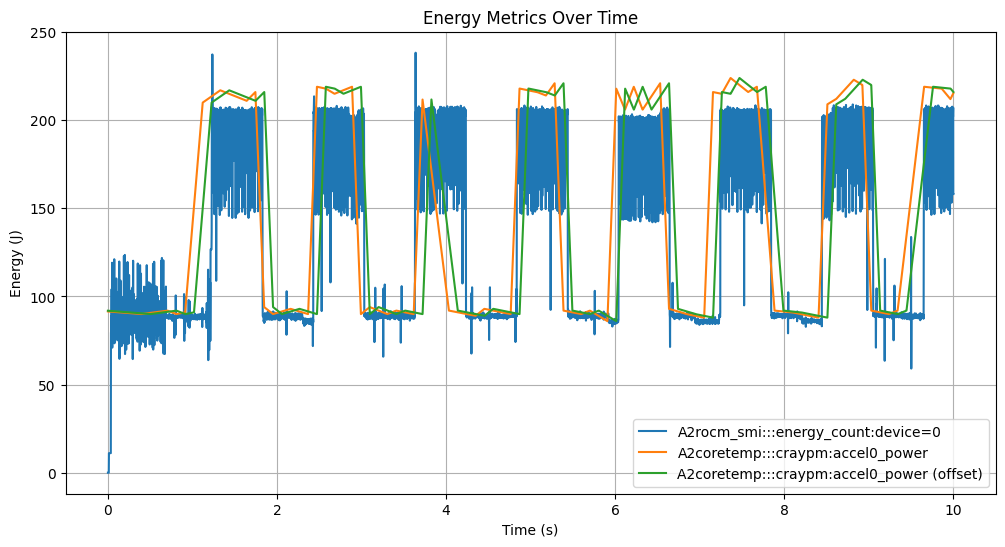

In [72]:
# Graph the rocm, cray, and cray offset by the time offset
def plot_metrics(metrics_df, time_offset: float):
    plt.figure(figsize=(12, 6))
    # Plot the first rocm energy metric
    rocm_metric = 'A2rocm_smi:::energy_count:device=0'
    cray_metric = 'A2coretemp:::craypm:accel0_power'
    df_rocm = numerical_derivative(sampled_to_continuous(metrics_df[metrics_df['Metric Name'] == rocm_metric]))
    df_cray = sampled_to_continuous(metrics_df[metrics_df['Metric Name'] == cray_metric])
    df_cray_offset = lambda t: sampled_to_continuous(metrics_df[metrics_df['Metric Name'] == cray_metric])(t + time_offset)
    
    x = np.linspace(0, 10, num=10000)
    y_rocm = df_rocm(x)
    y_cray = df_cray(x)
    y_cray_offset = df_cray_offset(x)
    plt.plot(x, y_rocm, label=rocm_metric)
    plt.plot(x, y_cray, label=cray_metric)
    plt.plot(x, y_cray_offset, label=f"{cray_metric} (offset)")
    # plt.plot(df_rocm['Time'], df_rocm['Value'] - df_rocm['Value'].min(), label=rocm_metric)
    # plt.plot(df_cray['Time'], df_cray['Value'] - df_cray['Value'].min(), label=cray_metric)
    # plt.plot(df_cray_offset['Time'], df_cray_offset['Value'] - df_cray_offset['Value'].min(), label=f"{cray_metric} (offset)")
    plt.xlabel('Time (s)')
    plt.ylabel('Energy (J)')
    plt.title('Energy Metrics Over Time')
    plt.legend()
    plt.grid()
    plt.show()
plot_metrics(traces[(IDLE_PERIODS_MS[0], ACTIVE_PERIODS_MS[0])][0], time_offset)